### Key Questions for Exploratory Data Analysis:

#### - Default Pattern Analysis
Does paying late more frequently lead to a higher default rate?

#### - Payment Behaviour
Does high total credit usage indicate financial stress that increases default risk?

#### - Financial Capacity
Does a high debt ratio combined with low income likely lead to default?

#### - Credit Exposure
Does having too many loans increase risk, and does having too few reduce credit history?

#### - Customer Profile
Do more financial dependents increase the financial burden and default risk?

### Import Libraries

In [245]:
import pandas as pd 
import numpy as np 

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick



### 1. Load Data & Initial Inspection

In [246]:
# Melakukan loading dataset dari file CSV
df = pd.read_csv("cs-training.csv")
df

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
149995,149996,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,149997,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,149998,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,149999,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [247]:
# Option B: Modifying in place
df.drop('Unnamed: 0', axis=1, inplace=True)
df

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
149995,0,0.040674,74,0,0.225131,2100.0,4,0,1,0,0.0
149996,0,0.299745,44,0,0.716562,5584.0,4,0,1,0,2.0
149997,0,0.246044,58,0,3870.000000,NaN,18,0,1,0,0.0
149998,0,0.000000,30,0,0.000000,5716.0,4,0,0,0,0.0


In [248]:
# Display jumlah data dan tipe data dari setiap kolom
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      150000 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 2   age                                   150000 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 4   DebtRatio                             150000 non-null  float64
 5   MonthlyIncome                         120269 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 7   NumberOfTimes90DaysLate               150000 non-null  int64  
 8   NumberRealEstateLoansOrLines          150000 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 10  NumberOfDependents                    146076 non-null  float64
dtype

In [249]:
df['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139974
1     10026
Name: count, dtype: int64

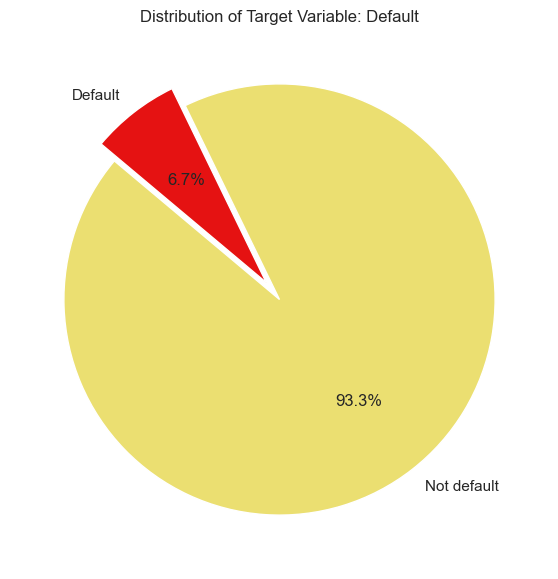

In [250]:

# Menghitung jumlah masing-masing kelas
data_pi = df['SeriousDlqin2yrs'].value_counts()

# Membuat Pie Chart
plt.figure(figsize=(7, 7))
plt.pie(data_pi, 
        labels=['Not default', 'Default'], 
        autopct='%1.1f%%', 
        startangle=140, 
        colors=["#EBDF71","#e51212"], 
        explode=[0, 0.1])  



plt.title('Distribution of Target Variable: Default')
plt.show()

##### Handle Duplicates

In [251]:
df.duplicated().sum()

609

In [252]:
df_no_dup = df.drop_duplicates()

In [253]:
df_no_dup.duplicated().sum()

0

### 2. Data Cleaning & Anomaly Handling

In [254]:
df_no_dup.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149391.0,0.066999,0.250021,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,149391.0,6.071087,250.263672,0.0,0.030132,0.154235,0.556494,50708.0
age,149391.0,52.306237,14.725962,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,149391.0,0.393886,3.852953,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,149391.0,354.436740,2041.843455,0.0,0.177441,0.368234,0.875279,329664.0
MonthlyIncome,120170.0,6675.098269,14389.582246,0.0,3400.000000,5400.000000,8250.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,149391.0,8.480892,5.136515,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,149391.0,0.238120,3.826165,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,149391.0,1.022391,1.130196,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,149391.0,0.212503,3.810523,0.0,0.000000,0.000000,0.000000,98.0


In [255]:
df_no_dup['SeriousDlqin2yrs'].value_counts()

SeriousDlqin2yrs
0    139382
1     10009
Name: count, dtype: int64

In [256]:
# 1. Validasi Statistik (IQR & Persentil)

def validate_constraints(df, column):
    # Hitung IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    upper_bound = Q3 + 1.5 * IQR
    
    # Hitung Persentil Ekstrem
    p99 = df[column].quantile(0.99)
    p999 = df[column].quantile(0.999)
    
    print(f"=== Validasi Kolom: {column} ===")
    print(f"Batas Atas Statistik (Q3 + 1.5*IQR): {upper_bound:.2f}")
    print(f"Persentil 99% (P99)                : {p99:.2f}")
    print(f"Persentil 99.9% (P99.9)            : {p999:.2f}")
    print(f"Nilai Maksimum Saat Ini            : {df[column].max():.2f}")
    print("-" * 40)

# Jalankan validasi pada kolom utama menggunakan data df_no_dup
target_cols = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'age', 'MonthlyIncome']
for col in target_cols:
    validate_constraints(df_no_dup, col)

=== Validasi Kolom: RevolvingUtilizationOfUnsecuredLines ===
Batas Atas Statistik (Q3 + 1.5*IQR): 1.35
Persentil 99% (P99)                : 1.09
Persentil 99.9% (P99.9)            : 1574.66
Nilai Maksimum Saat Ini            : 50708.00
----------------------------------------
=== Validasi Kolom: DebtRatio ===
Batas Atas Statistik (Q3 + 1.5*IQR): 1.92
Persentil 99% (P99)                : 4985.10
Persentil 99.9% (P99.9)            : 10658.14
Nilai Maksimum Saat Ini            : 329664.00
----------------------------------------
=== Validasi Kolom: age ===
Batas Atas Statistik (Q3 + 1.5*IQR): 96.00
Persentil 99% (P99)                : 87.00
Persentil 99.9% (P99.9)            : 94.00
Nilai Maksimum Saat Ini            : 109.00
----------------------------------------
=== Validasi Kolom: MonthlyIncome ===
Batas Atas Statistik (Q3 + 1.5*IQR): 15525.00
Persentil 99% (P99)                : 25000.00
Persentil 99.9% (P99.9)            : 78434.26
Nilai Maksimum Saat Ini            : 3008750.00
--

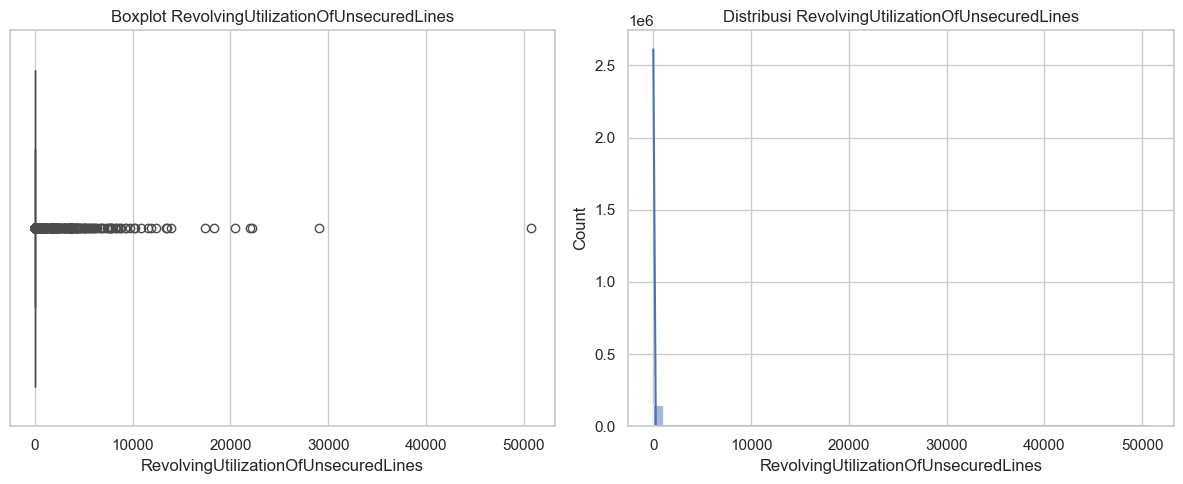

In [257]:
# 2. Visualisasi Sebaran


def plot_distribution(df, column):
    plt.figure(figsize=(12, 5))
    
    # Boxplot untuk melihat outlier secara visual
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[column])
    plt.title(f'Boxplot {column}')
    
    # Histogram untuk melihat konsentrasi data
    plt.subplot(1, 2, 2)
    sns.histplot(df[column], bins=50, kde=True)
    plt.title(f'Distribusi {column}')
    
    plt.tight_layout()
    plt.show()

# Contoh: Visualisasikan Revolving Utilization
plot_distribution(df_no_dup, 'RevolvingUtilizationOfUnsecuredLines')

Explanation for each value as a filter threshold:

- **Utilization Cleaning (Ratio Cap at 10):** Limits the maximum credit utilization to 10 to remove system errors (values in the tens of thousands) without discarding data from customers who are genuinely high spenders.
- **Delinquency System Code Correction (Values 96/98):** Removes delinquency counts of 96 or 98 because these are system codes for "Data Not Available," not actual late payment counts — they are logically impossible (equivalent to ~24 years of delays).
- **Debt Ratio Normalization (Max Cap at 1):** Limits the debt ratio to a maximum of 1 to correct inflated values caused by missing income data, so the model continues to reflect reasonable repayment capacity.
- **Missing Monthly Income Flag:** Adds a special indicator for missing income data to capture risk profile differences between customers who hide information and those who report it completely.

In [258]:
df_clean = df_no_dup.copy()

#  Delay
cols_late = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate'
]

for col in cols_late:
    df_clean.loc[df_clean[col] >= 90, col] = np.nan

#  RevolvingUtilization
df_clean.loc[df_clean['RevolvingUtilizationOfUnsecuredLines'] > 10, 
             'RevolvingUtilizationOfUnsecuredLines'] = np.nan

#  DebtRatio
df_clean.loc[df_clean['DebtRatio'] > 1, 'DebtRatio'] = np.nan

#  Age
df_clean.loc[df_clean['age'] < 18, 'age'] = np.nan
df_clean.loc[df_clean['age'] > 100, 'age'] = np.nan

#  Optional (tidak wajib langsung)
df_clean.loc[df_clean['MonthlyIncome'] > 1_000_000, 'MonthlyIncome'] = np.nan
df_clean.loc[df_clean['NumberOfDependents'] > 10, 'NumberOfDependents'] = np.nan

# Pinjaman Properti (Anomali Ekstrem)
df_clean.loc[df_clean['NumberRealEstateLoansOrLines'] > 15, 'NumberRealEstateLoansOrLines'] = np.nan

# Catatan: NumberOfOpenCreditLinesAndLoans dibiarkan karena distribusi masih logis.

In [259]:
df_clean.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,149391.0,0.066999,0.250021,0.0,0.000000,0.000000,0.000000,1.000000
RevolvingUtilizationOfUnsecuredLines,149150.0,0.322065,0.365943,0.0,0.030027,0.153564,0.553558,8.851852
age,149377.0,52.302115,14.718202,21.0,41.000000,52.000000,63.000000,99.000000
NumberOfTime30-59DaysPastDueNotWorse,149166.0,0.246725,0.698936,0.0,0.000000,0.000000,0.000000,13.000000
DebtRatio,114261.0,0.304590,0.225792,0.0,0.128991,0.275996,0.439161,1.000000
MonthlyIncome,120166.0,6613.444310,8714.406295,0.0,3400.000000,5400.000000,8250.000000,835040.000000
NumberOfOpenCreditLinesAndLoans,149391.0,8.480892,5.136515,0.0,5.000000,8.000000,11.000000,58.000000
NumberOfTimes90DaysLate,149166.0,0.090724,0.486352,0.0,0.000000,0.000000,0.000000,17.000000
NumberRealEstateLoansOrLines,149367.0,1.019014,1.093784,0.0,0.000000,1.000000,2.000000,15.000000
NumberOfTime60-89DaysPastDueNotWorse,149166.0,0.065068,0.330674,0.0,0.000000,0.000000,0.000000,11.000000


### 3. Handle Missing Values

In [260]:
df_clean.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines      241
age                                        14
NumberOfTime30-59DaysPastDueNotWorse      225
DebtRatio                               35130
MonthlyIncome                           29225
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   225
NumberRealEstateLoansOrLines               24
NumberOfTime60-89DaysPastDueNotWorse      225
NumberOfDependents                       3830
dtype: int64

In [261]:
(df_clean.isna().sum() / len(df_clean)).sort_values(ascending=False)

DebtRatio                               0.235155
MonthlyIncome                           0.195628
NumberOfDependents                      0.025637
RevolvingUtilizationOfUnsecuredLines    0.001613
NumberOfTime30-59DaysPastDueNotWorse    0.001506
NumberOfTimes90DaysLate                 0.001506
NumberOfTime60-89DaysPastDueNotWorse    0.001506
NumberRealEstateLoansOrLines            0.000161
age                                     0.000094
SeriousDlqin2yrs                        0.000000
NumberOfOpenCreditLinesAndLoans         0.000000
dtype: float64

- Based on the results, RevolvingUtilization, age, and delay columns with < 1% missing values are handled using simple median imputation.
- Moderate missing (~2–3%): `NumberOfDependents` is imputed with median or 0.
- High missing: `MonthlyIncome` (~19%) and `DebtRatio` (~23%) — filled with NaN if income is also missing; otherwise, light imputation is applied.

In [262]:
# kecil → isi median
df_clean['RevolvingUtilizationOfUnsecuredLines'].fillna(
    df_clean['RevolvingUtilizationOfUnsecuredLines'].median(), inplace=True)

df_clean['age'].fillna(df_clean['age'].median(), inplace=True)

df_clean['NumberOfDependents'].fillna(
    df_clean['NumberOfDependents'].median(), inplace=True)



C:\Users\HP\AppData\Local\Temp\ipykernel_12600\2136242766.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['RevolvingUtilizationOfUnsecuredLines'].fillna(
C:\Users\HP\AppData\Local\Temp\ipykernel_12600\2136242766.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

In [263]:
df_clean[df_clean['MonthlyIncome'].isna()]['DebtRatio'].describe()

count    1328.000000
mean        0.152871
std         0.359985
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: DebtRatio, dtype: float64

In [264]:
# kalau income missing → debt ratio juga dibuat NaN
df_clean.loc[df_clean['MonthlyIncome'].isna(), 'DebtRatio'] = np.nan

In [265]:
# TETAP NaN + tambahkan flag, NaN → 1 , Tidak NaN → 0
df_clean['income_missing_flag'] = df_clean['MonthlyIncome'].isna().astype(int)

In [266]:
df_clean.isnull().sum()

SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse      225
DebtRatio                               36458
MonthlyIncome                           29225
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                   225
NumberRealEstateLoansOrLines               24
NumberOfTime60-89DaysPastDueNotWorse      225
NumberOfDependents                          0
income_missing_flag                         0
dtype: int64

### 4. Exploratory Data Analysis

In [267]:
df_clean.groupby('income_missing_flag')['SeriousDlqin2yrs'].mean()

income_missing_flag
0    0.069529
1    0.056595
Name: SeriousDlqin2yrs, dtype: float64

### Visualizations

#### 1. Default Pattern Analysis

In [268]:
df_viz = df_clean.copy()

In [269]:
# buat kategori dan isi NAN jadi "Unknown"
df_viz['delay_bin'] = pd.cut(
    df_viz['NumberOfTimes90DaysLate'],
    bins=[-1, 0, 2, 5, 10, 20],
    labels=['0', '1-2', '3-5', '6-10', '>10']
)

df_viz['delay_bin'] = df_viz['delay_bin'].astype(str)
df_viz.loc[df_viz['NumberOfTimes90DaysLate'].isna(), 'delay_bin'] = 'Unknown'


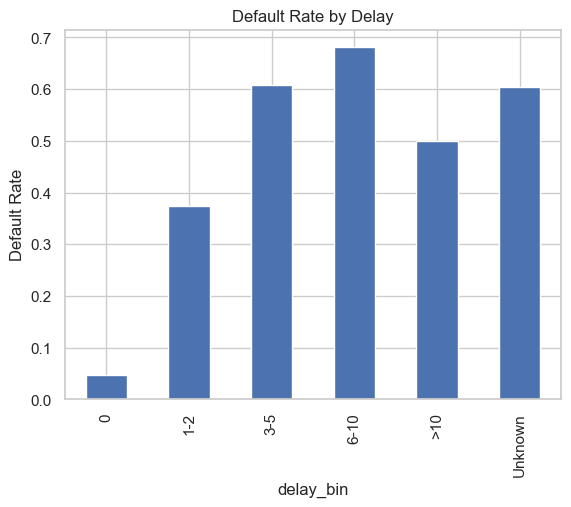

In [270]:
delay = df_viz.groupby('delay_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
delay.plot(kind='bar')
plt.title('Default Rate by Delay')
plt.ylabel('Default Rate')
plt.show()

#### Insight:

From the visualizations above, it is clear that 90-day late payments are a strong predictor of whether a customer will default. Some interesting observations: as the number of late payments increases from 6 to 10 times, the default rate rises steadily. However, at more than 10 times, the rate unexpectedly drops — this could be due to a smaller sample size at that range, or because banks intervene with borrowers who are frequently late. The "Unknown" category also shows a notably high default rate, which supports the decision to group these as "Unknown" rather than filling them with 0 or median, since this group tends to carry higher risk.

#### 2. Payment Behavior & Utilization (Credit Usage)

C:\Users\HP\AppData\Local\Temp\ipykernel_12600\138926641.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  util = df_viz.groupby('util_bin')['SeriousDlqin2yrs'].mean()


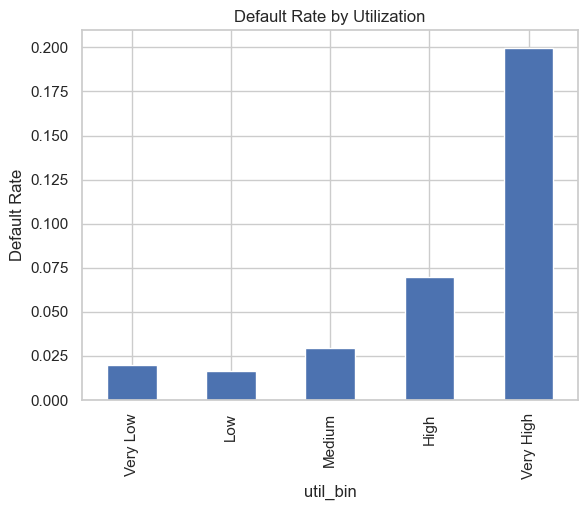

In [271]:
df_viz['util_bin'] = pd.qcut(
    df_viz['RevolvingUtilizationOfUnsecuredLines'],
    5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

util = df_viz.groupby('util_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
util.plot(kind='bar')
plt.title('Default Rate by Utilization')
plt.ylabel('Default Rate')
plt.show()

#### Insight:

Based on the chart above, higher credit utilization is associated with increased default risk.

#### 3. Financial Capacity (MonthlyIncome NaN values were intentionally kept as NaN to preserve data integrity; for this visualization they are grouped as 'Unknown')

In [272]:
df_viz['income_bin'] = pd.qcut(
    df_viz['MonthlyIncome'],
    4,
    labels=['Low', 'Medium', 'High', 'Very High']
)

df_viz['income_bin'] = df_viz['income_bin'].astype(str)
df_viz.loc[df_viz['MonthlyIncome'].isna(), 'income_bin'] = 'Unknown'

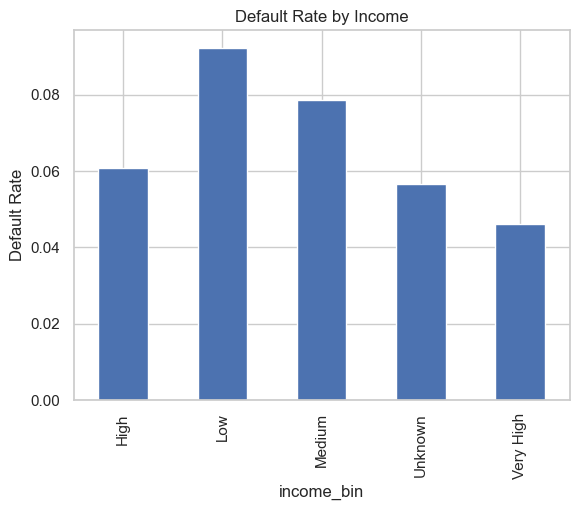

In [273]:
income = df_viz.groupby('income_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
income.plot(kind='bar')
plt.title('Default Rate by Income')
plt.ylabel('Default Rate')
plt.show()

#### Insight:

Based on the results, lower income tends to be associated with a higher default rate.

#### 4. Credit Exposure (Number of Credit Lines)

C:\Users\HP\AppData\Local\Temp\ipykernel_12600\1626572217.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  loan = df_viz.groupby('loan_bin')['SeriousDlqin2yrs'].mean()


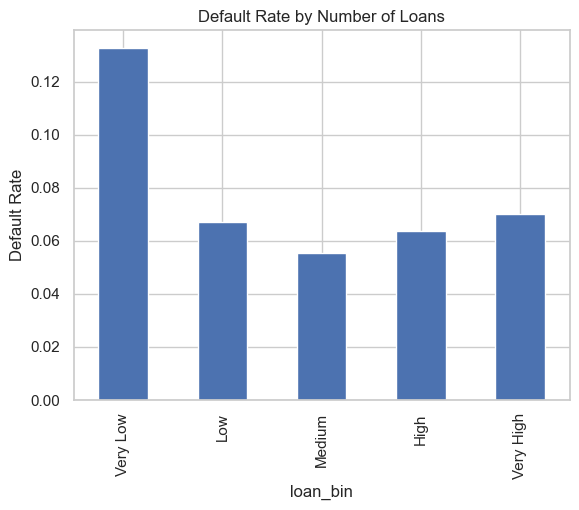

In [274]:
df_viz['loan_bin'] = pd.cut(
    df_viz['NumberOfOpenCreditLinesAndLoans'],
    bins=[-1, 2, 5, 10, 20, 60],
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)

loan = df_viz.groupby('loan_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
loan.plot(kind='bar')
plt.title('Default Rate by Number of Loans')
plt.ylabel('Default Rate')
plt.show()

In [275]:
df_viz['loan_bin'].value_counts()

loan_bin
Medium       60386
High         39030
Low          33474
Very Low     12521
Very High     3980
Name: count, dtype: int64

#### Insight:

Having very few accounts (very low) carries higher risk — possibly because the borrower lacks credit history or is a new customer whose behavior hasn't been tested. There are 12,521 data points in this group showing risky behavior. A moderate number of accounts tends to be more stable and reliable, with 60,386 data points suggesting this is a relatively safe zone. Having too many accounts (very high) starts to show increasing risk, with 3,980 data points — the smallest sample but still worth monitoring.

#### 5. Customer Profile (Number of Dependents)

C:\Users\HP\AppData\Local\Temp\ipykernel_12600\1877778790.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dep = df_viz.groupby('dep_bin')['SeriousDlqin2yrs'].mean()


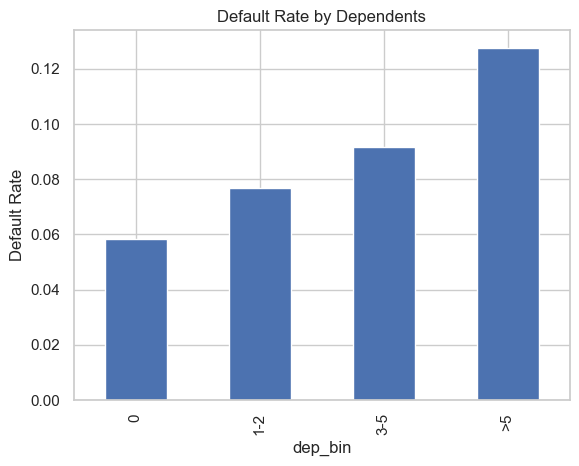

In [276]:
df_viz['dep_bin'] = pd.cut(
    df_viz['NumberOfDependents'],
    bins=[-1, 0, 2, 5, 10],
    labels=['0', '1-2', '3-5', '>5']
)

dep = df_viz.groupby('dep_bin')['SeriousDlqin2yrs'].mean()

plt.figure()
dep.plot(kind='bar')
plt.title('Default Rate by Dependents')
plt.ylabel('Default Rate')
plt.show()

#### Insight:

The more financial dependents a borrower has, the higher the default risk — because financial burden increases accordingly.

#### Dashboard

C:\Users\HP\AppData\Local\Temp\ipykernel_12600\1099170140.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='age_bin', y='SeriousDlqin2yrs', data=df_dash,
C:\Users\HP\AppData\Local\Temp\ipykernel_12600\1099170140.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='income_bin', y='SeriousDlqin2yrs', data=df_dash,
C:\Users\HP\AppData\Local\Temp\ipykernel_12600\1099170140.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='NumberOfDependents', y='SeriousDlqin2yrs', data=df_dash,
C:\Users\HP\AppData\Local\Temp\ipykernel_12600\109917

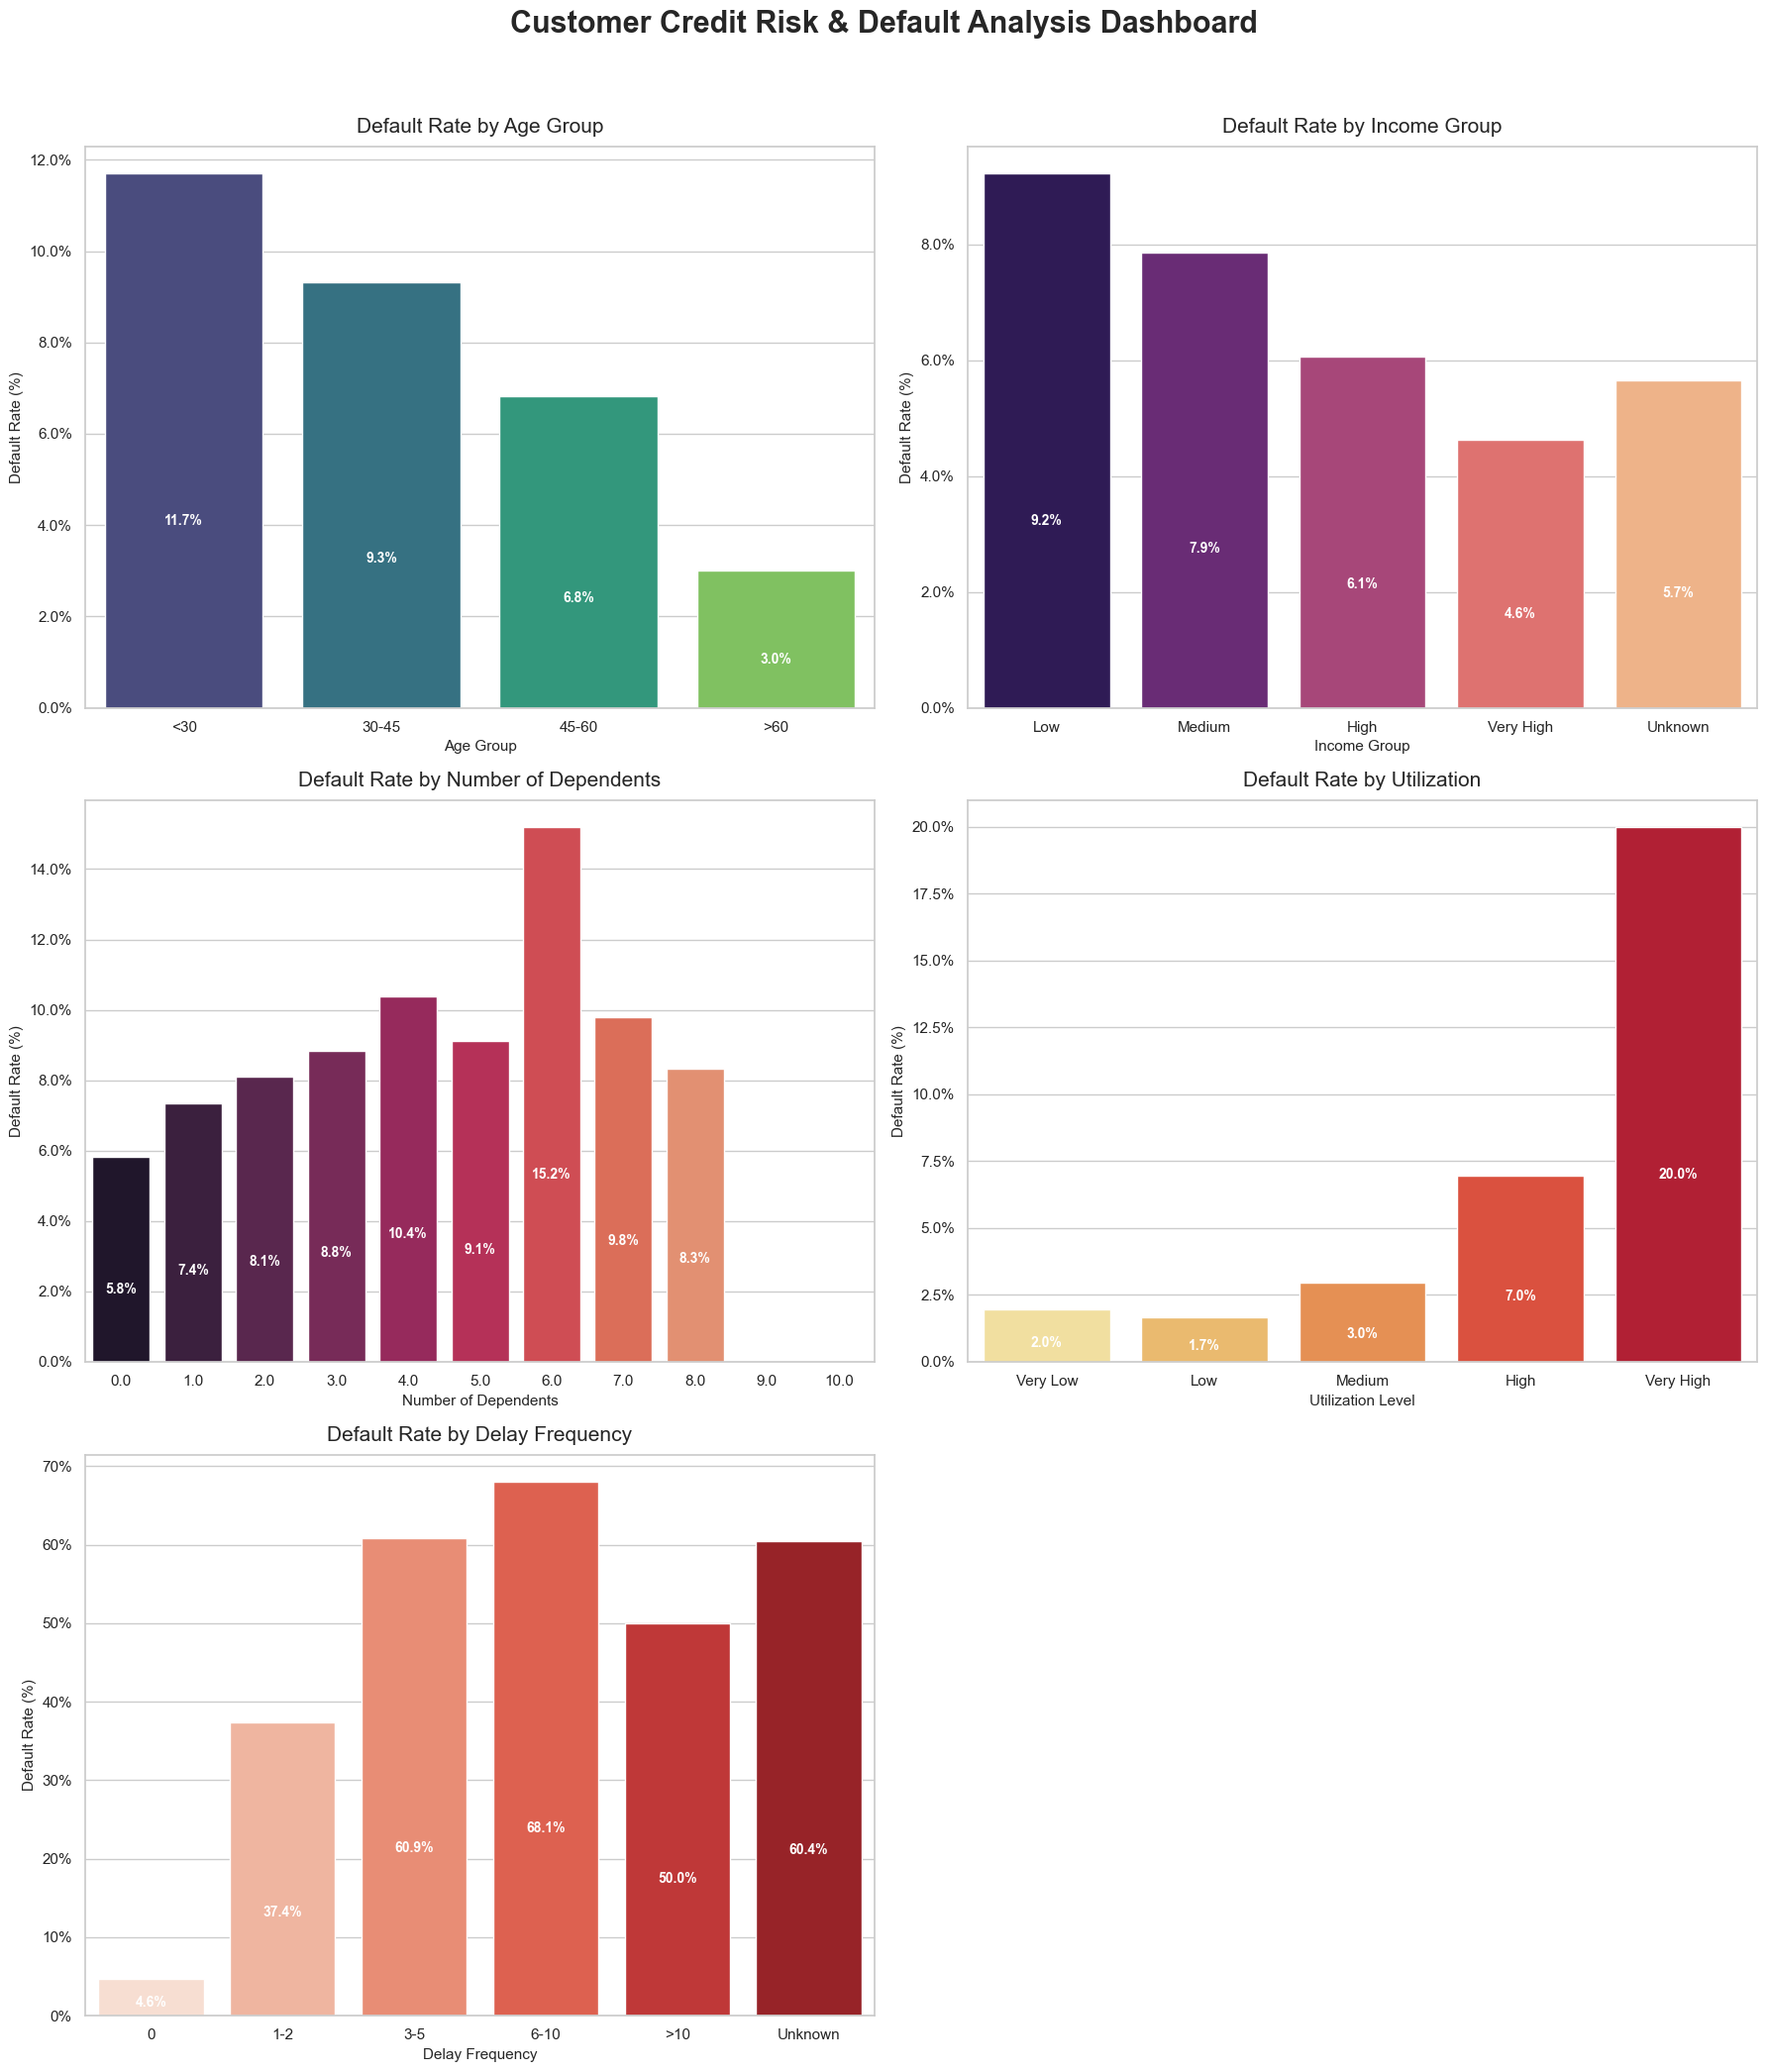

In [277]:
# 1. Persiapan Data
df_dash = df_viz.copy()

# --- BINNING PROCESS ---
age_bins = [0, 30, 45, 60, 120]
age_labels = ['<30', '30-45', '45-60', '>60']
df_dash['age_bin'] = pd.cut(df_dash['age'], bins=age_bins, labels=age_labels)

income_order = ['Low', 'Medium', 'High', 'Very High', 'Unknown']
df_dash['income_bin'] = pd.Categorical(df_dash['income_bin'], categories=income_order, ordered=True)

util_order = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
df_dash['util_bin'] = pd.Categorical(df_dash['util_bin'], categories=util_order, ordered=True)

delay_order = ['0', '1-2', '3-5', '6-10', '>10', 'Unknown']
df_dash['delay_bin'] = pd.Categorical(df_dash['delay_bin'], categories=delay_order, ordered=True)

# --- HELPER FUNCTIONS ---
def format_ax(ax, title, xlabel, ylabel='Default Rate (%)'):
    ax.set_title(title, fontsize=15, pad=10)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))

def add_bar_labels(ax, fontsize=10, color='white', fontweight='bold', padding_ratio=0.35):
    """
    Tulis label persen di tengah tiap bar.
    padding_ratio: posisi vertikal label = tinggi_bar * ratio
                   0.0 = dasar bar, 0.5 = tengah, 1.0 = puncak bar
    """
    for patch in ax.patches:
        height = patch.get_height()
        if height > 0:                          # skip bar kosong / NaN
            x = patch.get_x() + patch.get_width() / 2   # tengah horizontal bar
            y = height * padding_ratio                    # posisi vertikal di dalam bar
            ax.text(
                x, y,
                f'{height:.1%}',               # format: 0.092 → "9.2%"
                ha='center', va='center',
                fontsize=fontsize,
                fontweight=fontweight,
                color=color
            )

# --- DASHBOARD VISUALIZATION ---
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 2, figsize=(18, 22))
plt.subplots_adjust(hspace=0.4, wspace=0.25)
fig.suptitle('Customer Credit Risk & Default Analysis Dashboard',
             fontsize=22, fontweight='bold', y=0.95)

# Plot 1: Age Group
sns.barplot(x='age_bin', y='SeriousDlqin2yrs', data=df_dash,
            ax=axes[0,0], palette='viridis', errorbar=None)
format_ax(axes[0,0], 'Default Rate by Age Group', 'Age Group')
add_bar_labels(axes[0,0])

# Plot 2: Income Group
sns.barplot(x='income_bin', y='SeriousDlqin2yrs', data=df_dash,
            ax=axes[0,1], palette='magma', errorbar=None, order=income_order)
format_ax(axes[0,1], 'Default Rate by Income Group', 'Income Group')
add_bar_labels(axes[0,1])

# Plot 3: Dependents
sns.barplot(x='NumberOfDependents', y='SeriousDlqin2yrs', data=df_dash,
            ax=axes[1,0], palette='rocket', errorbar=None)
format_ax(axes[1,0], 'Default Rate by Number of Dependents', 'Number of Dependents')
add_bar_labels(axes[1,0])

# Plot 4: Utilization
sns.barplot(x='util_bin', y='SeriousDlqin2yrs', data=df_dash,
            ax=axes[1,1], palette='YlOrRd', errorbar=None, order=util_order)
format_ax(axes[1,1], 'Default Rate by Utilization', 'Utilization Level')
add_bar_labels(axes[1,1])

# Plot 5: Delay Frequency
sns.barplot(x='delay_bin', y='SeriousDlqin2yrs', data=df_dash,
            ax=axes[2,0], palette='Reds', errorbar=None, order=delay_order)
format_ax(axes[2,0], 'Default Rate by Delay Frequency', 'Delay Frequency')
add_bar_labels(axes[2,0])

# Plot 6: Dihilangkan (Hanya membersihkan area agar tidak ada garis grid)
axes[2,1].axis('off')


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [278]:
print("\n" + "="*80)
print("KESIMPULAN AKHIR")
print("="*80)
print("""
Berdasarkan EDA yang telah dilakukan pada 150.000 data nasabah:

1. Keterlambatan pembayaran adalah prediktor terkuat default rate
2. Penggunaan kredit tinggi (>60%) mengindikasikan tekanan finansial
3. Income rendah dan debt ratio tinggi meningkatkan risiko default
4. Customer dengan tanggungan >2 orang memiliki risiko lebih tinggi
5. untuk credit exposure/jumlah pinjaman very low dan high sama-sama berisiko, optimal di medium exposure

Dashboard di atas dapat digunakan untuk:
- Justifikasi fitur dalam model machine learning
- Menentukan threshold risiko untuk approval
- Segmentasi customer berdasarkan profil risiko
""")


KESIMPULAN AKHIR

Berdasarkan EDA yang telah dilakukan pada 150.000 data nasabah:

1. Keterlambatan pembayaran adalah prediktor terkuat default rate
2. Penggunaan kredit tinggi (>60%) mengindikasikan tekanan finansial
3. Income rendah dan debt ratio tinggi meningkatkan risiko default
4. Customer dengan tanggungan >2 orang memiliki risiko lebih tinggi
5. untuk credit exposure/jumlah pinjaman very low dan high sama-sama berisiko, optimal di medium exposure

Dashboard di atas dapat digunakan untuk:
- Justifikasi fitur dalam model machine learning
- Menentukan threshold risiko untuk approval
- Segmentasi customer berdasarkan profil risiko

